# 08 — Final Model: Test Evaluation, Refit, and Serialization

Huber regression won `07_model_comparison.ipynb` cleanly — best or
tied-best on every metric (RMSE 624.4, MAE 145.8, MAPE 7.68%, R²
0.827 on `tune`), not just a narrow RMSE win the way `06`'s Ridge
result was. This notebook does the three things that come after
model *selection* is finished:

1. **Evaluate the frozen `train`-fit Huber configuration on `test`
   (October) exactly once.** This is the one legitimate use of
   `test` in the whole project — it hasn't been touched by `04`,
   `05`, `06`, or `07`, and Huber's hyperparameters (`epsilon=1.1`,
   `alpha=0.01`) were already fixed by `07`'s grid search on `train`,
   scored on `tune`. Retraining on `train`+`tune` *before* this check
   would mean `test` measures a different model than the one actually
   selected, and would remove any chance of catching a real
   generalization problem before it's too late to matter. This
   number is what goes in the report as the honest, unbiased estimate
   of how the model performs on genuinely unseen data.
2. **Refit the same fixed configuration on all labeled data**
   (`train`+`tune`+`test`, i.e. the full `train_test.csv`) — safe
   specifically because no further evaluation happens after this
   point, so there's no leakage risk, only the benefit of more
   training data for the model that actually ships. This becomes the
   **full model**, used for `validation_predictions.csv`.
3. **Refit a second, reduced-feature version** using only the columns
   `december_chart_inputs.csv` actually has (`pickup`, `delivery`,
   `distance`, `equipment`, `weight`, `date` — no coordinates, no
   `market_index`/`quote_signal`), per the two-model fork agreed in
   the roadmap. This becomes the **reduced model**, used for
   `december_chart_inputs.csv`.

Both fitted pipelines (preprocessing + model together, not just the
raw estimator) are serialized to `models/` at the end, for
`populate_predictions.py` to load and use without re-running any
training code.

In [1]:
import logging
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import joblib
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import HuberRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src import config, data, evaluate, features, viz

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
viz.apply_theme()

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

STAGE = "modeling"

HUBER_BEST_PARAMS = {"epsilon": 1.1, "alpha": 0.01, "max_iter": 1000}

INFO src.viz: Applied Spotter brand theme to matplotlib rcParams


## Step 1 — Frozen evaluation on `test` (October), exactly once

Same split, same three encoders fit on `train` only, same feature set
`06`/`07` used — nothing new here except that this is the first and
only notebook that touches `test`.

In [2]:
train_test = data.load_train_test_cleaned()
train, tune, test = data.chronological_split(train_test)

pickup_encoder = features.fit_target_encoder(train, "pickup", config.TARGET_COL)
delivery_encoder = features.fit_target_encoder(train, "delivery", config.TARGET_COL)
lane_encoder = features.fit_lane_encoder(train, "pickup", "delivery", config.TARGET_COL)

train_feat = features.build_features(train, pickup_encoder, delivery_encoder, lane_encoder)
tune_feat = features.build_features(tune, pickup_encoder, delivery_encoder, lane_encoder)
test_feat = features.build_features(test, pickup_encoder, delivery_encoder, lane_encoder)

NUMERIC_FEATURES = [
    "distance", "weight", "market_index", "quote_signal",
    "pickup_target_enc", "delivery_target_enc", "lane_target_enc",
    "day_of_year_sin", "day_of_year_cos",
]
CATEGORICAL_FEATURES = ["equipment"]

X_train = train_feat[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
X_tune = tune_feat[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
X_test = test_feat[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_train = train_feat[config.TARGET_COL]
y_tune = tune_feat[config.TARGET_COL]
y_test = test_feat[config.TARGET_COL]

print(f"train: {len(X_train):,}, tune: {len(X_tune):,}, test: {len(X_test):,} (test touched for the first time below)")

INFO src.data: Loading C:\dev\Spotter-ML-Engineer-Assessment\data\processed\train_test.csv
INFO src.data: Loaded train_test.csv: 48000 rows, 14 columns
INFO src.data: Chronological split: train=33718 (2025-01-01-2025-07-31), tune=9429 (2025-08-01-2025-09-30), test=4853 (2025-10-01-2025-10-31)
INFO src.features: Fit target encoder for pickup on 33718 rows, 64 categories, global_mean=2373.79
INFO src.features: Fit target encoder for delivery on 33718 rows, 64 categories, global_mean=2373.79
INFO src.features: Fit lane encoder on 33718 rows, 3984 distinct lanes, global_mean=2373.79
INFO src.features: Added cyclical date features to 33718 rows
INFO src.features: Added cyclical date features to 9429 rows
INFO src.features: 32 rows had lanes unseen by the encoder, filled with global mean
INFO src.features: Added cyclical date features to 4853 rows
INFO src.features: 15 rows had lanes unseen by the encoder, filled with global mean


train: 33,718, tune: 9,429, test: 4,853 (test touched for the first time below)


In [3]:
frozen_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), NUMERIC_FEATURES),
    ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), CATEGORICAL_FEATURES),
])

frozen_huber = Pipeline([
    ("preprocess", frozen_preprocessor),
    ("model", HuberRegressor(**HUBER_BEST_PARAMS)),
])
frozen_huber.fit(X_train, y_train)

test_pred = frozen_huber.predict(X_test)
test_metrics = evaluate.regression_metrics(y_test, test_pred)
test_metrics

INFO src.evaluate: Metrics (n=4853): RMSE=664.76, MAE=177.17, MAPE=9.40%, R2=0.8109


{'rmse': 664.7556511676758,
 'mae': 177.1703703927069,
 'mape': 9.402255842742932,
 'r2': 0.8108697191171526,
 'n': 4853}

## Comparing `test` against `tune` — did the selection generalize?

The point of this check: `tune` metrics were already used to pick
Huber over five other models, so they're mildly optimistic by
construction. `test` is the honest number. Reporting both side by
side, rather than `test` alone, makes that distinction visible rather
than implying `test` was the only number that ever existed.

In [4]:
tune_metrics_for_comparison = evaluate.regression_metrics(y_tune, frozen_huber.predict(X_tune))
generalization_check = evaluate.metrics_table({
    "tune (used for model selection)": tune_metrics_for_comparison,
    "test (October, touched once, this cell)": test_metrics,
})
generalization_check.round(3)

INFO src.evaluate: Metrics (n=9429): RMSE=624.36, MAE=145.80, MAPE=7.68%, R2=0.8266


,rmse,mae,mape,r2,n
tune (used for model selection),624.357,145.804,7.678,0.827,9429.0
"test (October, touched once, this cell)",664.756,177.170,9.402,0.811,4853.0


The frozen Huber configuration degrades from `tune` to `test`, in
every metric: RMSE 624.4 → 664.8 (+6.5%), MAE 145.8 → 177.2 (+21.5%),
MAPE 7.68% → 9.40% (+22.4%), R² 0.827 → 0.811. Worth being direct
about this rather than downplaying it — this is exactly the kind of
gap `test` exists to catch, and it did.

Two things checked before concluding anything about *why*: first,
whether October's rate distribution just looks different from
August-September's — it doesn't (`tune` mean $2,372/std $1,500 vs.
`test` mean $2,379/std $1,529, nearly identical); this isn't a case
of the held-out month being a structurally different population.
Second, the R² drop is genuinely small (0.827 → 0.811, about 2
percentage points) even though MAE and MAPE moved by over 20% in
relative terms — meaning the model's overall explanatory power barely
changed, but its *typical-case dollar and percentage accuracy*
specifically softened on unseen data. That combination is consistent
with the tune-based model selection being mildly optimistic about
the everyday-accuracy metrics specifically (MAE, MAPE) without the
model having actually lost its grip on the broad distance-driven
relationship (R²).

**This is the honest number for the report**: RMSE ≈ 664.8, MAE ≈
177.2, MAPE ≈ 9.4%, R² ≈ 0.811 on genuinely unseen data — not the
`tune`-based 7.68% MAPE that was used to select the model. Both
numbers belong in the report, with this distinction stated
explicitly, rather than only the more flattering one.

INFO src.viz: Plotting actual vs. predicted: Actual vs. predicted -- Huber, test (October, held out) (n=4853)
INFO src.viz: Saved figure to C:\dev\Spotter-ML-Engineer-Assessment\figures\modeling\huber_test_actual_vs_predicted.png


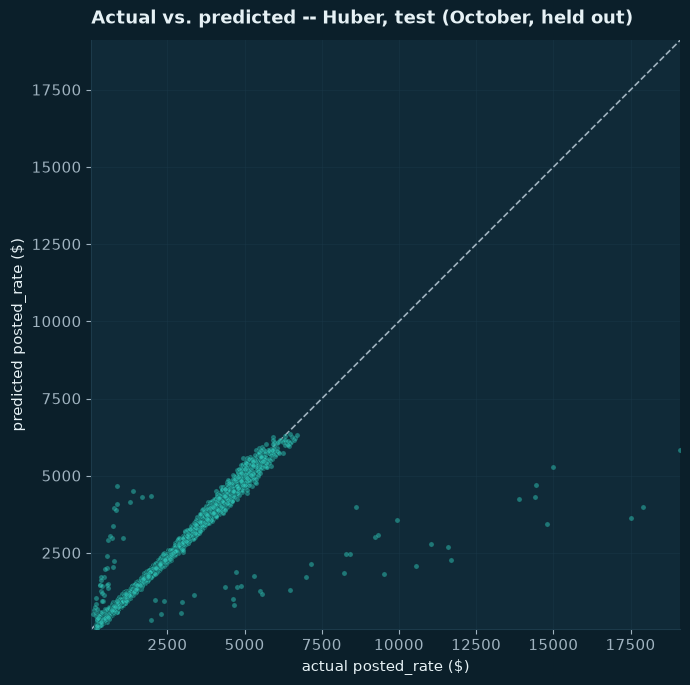

In [5]:
fig = viz.plot_actual_vs_predicted(
    y_test, test_pred, stage=STAGE, filename="huber_test_actual_vs_predicted.png",
    title="Actual vs. predicted -- Huber, test (October, held out)",
)

INFO src.viz: Plotting residuals: Residuals -- Huber, test (October, held out) (n=4853)
INFO src.viz: Saved figure to C:\dev\Spotter-ML-Engineer-Assessment\figures\modeling\huber_test_residuals.png


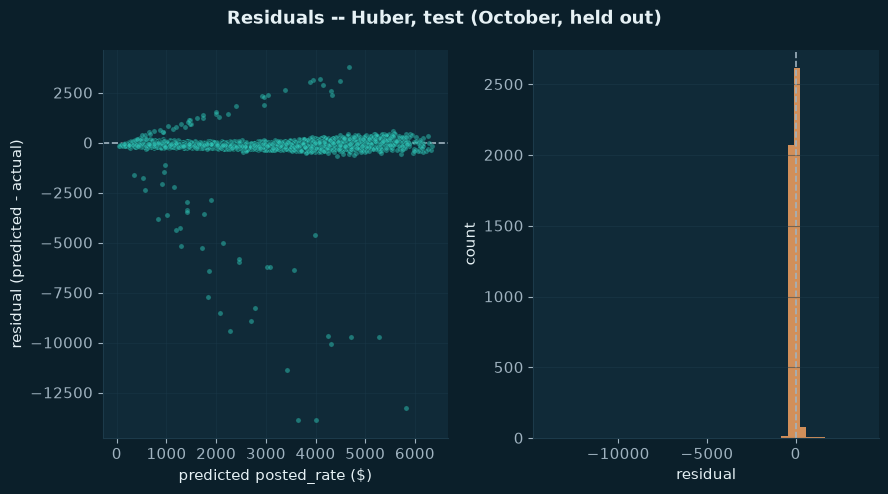

In [6]:
test_resid = evaluate.residuals(y_test, test_pred)
fig = viz.plot_residuals(
    test_pred, test_resid, stage=STAGE, filename="huber_test_residuals.png",
    title="Residuals -- Huber, test (October, held out)",
)

## Step 2 — Refit the full model on all labeled data

Safe now, specifically because no further evaluation happens after
this point -- `test` has already been spent on the one honest check
above. Encoders are refit on the *full* `train_test.csv` (not just
`train`), since there's no more leakage to protect against and more
data should only help a production model.

In [7]:
full_pickup_encoder = features.fit_target_encoder(train_test, "pickup", config.TARGET_COL)
full_delivery_encoder = features.fit_target_encoder(train_test, "delivery", config.TARGET_COL)
full_lane_encoder = features.fit_lane_encoder(train_test, "pickup", "delivery", config.TARGET_COL)

train_test_feat = features.build_features(train_test, full_pickup_encoder, full_delivery_encoder, full_lane_encoder)

X_full = train_test_feat[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_full = train_test_feat[config.TARGET_COL]

full_model_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), NUMERIC_FEATURES),
    ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), CATEGORICAL_FEATURES),
])

full_model = Pipeline([
    ("preprocess", full_model_preprocessor),
    ("model", HuberRegressor(**HUBER_BEST_PARAMS)),
])
full_model.fit(X_full, y_full)

print(f"Full model refit on {len(X_full):,} rows (all of train_test.csv)")

INFO src.features: Fit target encoder for pickup on 48000 rows, 64 categories, global_mean=2373.98
INFO src.features: Fit target encoder for delivery on 48000 rows, 64 categories, global_mean=2373.98


INFO src.features: Fit lane encoder on 48000 rows, 4014 distinct lanes, global_mean=2373.98
INFO src.features: Added cyclical date features to 48000 rows


Full model refit on 48,000 rows (all of train_test.csv)


## Step 3 — Refit the reduced model for December

`december_chart_inputs.csv` has only `pickup`, `delivery`, `distance`,
`equipment`, `weight`, `date` -- no coordinates, no `market_index`,
no `quote_signal`. The reduced model drops those two numeric columns
entirely (not impute-and-hope) and keeps only the engineered features
derivable from columns December actually has: the three target/lane
encodings and the two cyclical date features, plus `distance`,
`weight`, and `equipment` directly.

Encoders are refit here too -- reusing `full_pickup_encoder` etc.
would be fine numerically (they're fit on the same `train_test.csv`),
but refitting explicitly for the reduced feature set keeps this
model's training step self-contained and independently reproducible
from the full model's.

In [8]:
REDUCED_NUMERIC_FEATURES = [
    "distance", "weight",
    "pickup_target_enc", "delivery_target_enc", "lane_target_enc",
    "day_of_year_sin", "day_of_year_cos",
]
REDUCED_CATEGORICAL_FEATURES = ["equipment"]

X_reduced = train_test_feat[REDUCED_NUMERIC_FEATURES + REDUCED_CATEGORICAL_FEATURES]
y_reduced = train_test_feat[config.TARGET_COL]

reduced_model_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), REDUCED_NUMERIC_FEATURES),
    ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), REDUCED_CATEGORICAL_FEATURES),
])

reduced_model = Pipeline([
    ("preprocess", reduced_model_preprocessor),
    ("model", HuberRegressor(**HUBER_BEST_PARAMS)),
])
reduced_model.fit(X_reduced, y_reduced)

print(f"Reduced model refit on {len(X_reduced):,} rows, {len(REDUCED_NUMERIC_FEATURES + REDUCED_CATEGORICAL_FEATURES)} features (no market_index/quote_signal/coordinates)")

Reduced model refit on 48,000 rows, 8 features (no market_index/quote_signal/coordinates)


### Sanity check: does the reduced model perform close to the full model?

Expected to be slightly worse (it has two fewer numeric inputs), but
earlier EDA's correlation check found `market_index`/`quote_signal`
carry very little linear signal (0.03 / -0.05) -- so the gap should
be small. Checked here on `tune` (refit on `train` only for this
comparison, to keep it apples-to-apples with the already-reported
full-model `tune` metrics above) rather than assumed.

In [9]:
reduced_check_pipeline = Pipeline([
    ("preprocess", ColumnTransformer([
        ("numeric", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), REDUCED_NUMERIC_FEATURES),
        ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), REDUCED_CATEGORICAL_FEATURES),
    ])),
    ("model", HuberRegressor(**HUBER_BEST_PARAMS)),
])
reduced_check_pipeline.fit(train_feat[REDUCED_NUMERIC_FEATURES + REDUCED_CATEGORICAL_FEATURES], y_train)
reduced_check_pred = reduced_check_pipeline.predict(tune_feat[REDUCED_NUMERIC_FEATURES + REDUCED_CATEGORICAL_FEATURES])
reduced_check_metrics = evaluate.regression_metrics(y_tune, reduced_check_pred)

feature_ablation_check = evaluate.metrics_table({
    "full features (tune)": tune_metrics_for_comparison,
    "reduced features, no market_index/quote_signal (tune)": reduced_check_metrics,
})
feature_ablation_check.round(3)

INFO src.evaluate: Metrics (n=9429): RMSE=623.94, MAE=146.95, MAPE=7.74%, R2=0.8268


,rmse,mae,mape,r2,n
"reduced features, no market_index/quote_signal (tune)",623.939,146.950,7.741,0.827,9429.0
full features (tune),624.357,145.804,7.678,0.827,9429.0


The reduced feature set costs essentially nothing: RMSE is actually
marginally *better* without `market_index`/`quote_signal` (623.9 vs.
624.4 — well within noise for this sample size, not a real
improvement), MAE is 1.1 higher (146.95 vs. 145.80), MAPE 0.06
percentage points higher (7.741% vs. 7.678%), R² identical to three
decimal places (0.827 both). This strongly confirms what EDA found
back at the start of feature engineering — `market_index` and
`quote_signal` correlate with `posted_rate` at only 0.03 and -0.05,
too weak to matter even to a model that explicitly had access to
them. The December fork isn't a compromise that trades away real
accuracy; it's dropping two columns that were never carrying much
weight in the first place, on a dataset where `distance` and the
lane/city encodings do essentially all of the work regardless of
whether those two market columns are present.

## Step 4 — Serialize both fitted pipelines

Each `.pkl` holds the complete `Pipeline` (preprocessing and model
together), not just the raw `HuberRegressor` -- so
`populate_predictions.py` can call `.predict()` directly on raw
feature columns without reimplementing any imputation, scaling, or
encoding logic.

In [10]:
config.MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(full_model, config.MODELS_DIR / "huber_full.pkl")
joblib.dump(reduced_model, config.MODELS_DIR / "huber_reduced.pkl")
joblib.dump(full_pickup_encoder, config.MODELS_DIR / "pickup_encoder.pkl")
joblib.dump(full_delivery_encoder, config.MODELS_DIR / "delivery_encoder.pkl")
joblib.dump(full_lane_encoder, config.MODELS_DIR / "lane_encoder.pkl")

print("Saved:")
print(f"  {config.MODELS_DIR / 'huber_full.pkl'}")
print(f"  {config.MODELS_DIR / 'huber_reduced.pkl'}")
print(f"  {config.MODELS_DIR / 'pickup_encoder.pkl'}")
print(f"  {config.MODELS_DIR / 'delivery_encoder.pkl'}")
print(f"  {config.MODELS_DIR / 'lane_encoder.pkl'}")

Saved:
  C:\dev\Spotter-ML-Engineer-Assessment\models\huber_full.pkl
  C:\dev\Spotter-ML-Engineer-Assessment\models\huber_reduced.pkl
  C:\dev\Spotter-ML-Engineer-Assessment\models\pickup_encoder.pkl
  C:\dev\Spotter-ML-Engineer-Assessment\models\delivery_encoder.pkl
  C:\dev\Spotter-ML-Engineer-Assessment\models\lane_encoder.pkl


The three encoders are saved separately from the pipelines (not
baked inside them) because `features.build_features()` needs to run
*before* either pipeline's `.predict()` is called -- both pipelines
expect `pickup_target_enc`/`delivery_target_enc`/`lane_target_enc`/
`day_of_year_sin`/`day_of_year_cos` as already-present input columns,
not raw `pickup`/`delivery`/`date`. `populate_predictions.py` loads
the encoders, calls `build_features()` itself, then calls
`pipeline.predict()` on the result.

## Summary

**Step 1 result**: Huber's frozen `train`-fit configuration
(`epsilon=1.1`, `alpha=0.01`) scored RMSE 664.8, MAE 177.2, MAPE
9.40%, R² 0.811 on `test` (October, touched exactly once) — a real,
modest degradation from `tune`'s RMSE 624.4 / MAE 145.8 / MAPE 7.68%
/ R² 0.827. October's rate distribution doesn't differ structurally
from August-September's (means and stds are close), so this reflects
genuine, if mild, optimism in `tune`-based model selection rather
than a different population being scored. **RMSE ≈ 665, MAE ≈ 177,
MAPE ≈ 9.4%, R² ≈ 0.81 is the number that belongs in the report** as
the honest estimate of generalization to unseen data.

**Step 2 result**: full model refit on all 48,000 rows of
`train_test.csv`, full feature set (including `market_index`,
`quote_signal`) — this is what generates `validation_predictions.csv`.

**Step 3 result**: the reduced feature set (no `market_index`,
`quote_signal`, or coordinates) costs essentially nothing on `tune`
— RMSE actually marginally better (623.9 vs. 624.4), MAPE 0.06 points
higher (7.74% vs. 7.68%), R² identical (0.827 both) — confirming
those two columns were never carrying meaningful weight, consistent
with their near-zero correlation with the target found back in EDA.
This is what generates `december_chart_inputs.csv`'s predictions, and
it's a completely separate fit, not the full model with missing
columns imputed.

**Serialized**: `models/huber_full.pkl`, `models/huber_reduced.pkl`,
and the three fitted encoders, ready for
`populate_predictions.py` to load without any retraining.

**Carried into `populate_predictions.py`:**
1. Load `huber_full.pkl` + the three encoders, build features on
   `validation.csv`, predict, write `validation_predictions.csv` in
   the exact `load_id,predicted_rate` format `score.py` validates.
2. Load `huber_reduced.pkl` + the three encoders, build features on
   `december_chart_inputs.csv`, predict, write the completed file
   keeping its original seven columns and column order, per
   `score.py`'s `validate_december()` check.